# 좋은 정류장이란 무엇일까?

---

##  프로젝트 목표
> **“좋은 정류장과 나쁜 정류장을 데이터를 기반으로 정의하기”**

단순히 이용량이 많은 정류장이 좋은 정류장일까?  
이번 프로젝트의 목표는 **승하차 데이터**를 활용하여  
**‘좋은 정류장’의 기준을 스스로 정의하고, 이를 수치화하는 것**이다.  

---

## 문제의식
- 우리가 가진 데이터는 **승차 인원, 하차 인원, 노선, 이용일자(또는 년월)** 정도이다.  
- 즉, 정류장의 ‘위치’나 ‘주변 시설’ 같은 외부 요인은 없고,  
  **이용 패턴 자체로 정류장의 특성을 해석해야 한다.**
- 그렇다면, 단순히 많이 이용된다고 해서 좋은 정류장일까?  
  → 꼭 그렇지는 않다. ‘균형’, ‘지속성’, ‘효율성’ 등도 함께 고려해야 한다.  

---

## 분석 방향성
1. **기초 EDA (Exploratory Data Analysis)**  
   - 전체적인 승하차 규모, 노선별·정류장별 이용 분포 확인  
   - 이용량의 시간적 패턴(월별, 요일별 등) 탐색  
   - 데이터의 특성과 이상치 파악  

2. **지표 설계 (Indicator Design)**  
   > 데이터를 단순히 보는 것에서 나아가,  
   > **‘좋은 정류장’을 정의할 수 있는 기준을 직접 만든다.**
   - 예시 기준  
     - 이용량지수: 얼마나 많이 이용되는가  
     - 균형지수: 승차와 하차가 얼마나 균형 잡혀 있는가  
     - 안정성지수: 월별 변동이 얼마나 적은가  
     - 효율성지수: 승차 대비 하차 비율  

3. **지표 통합 및 비교**  
   - 위 지표들을 조합해 종합 점수를 산출하고,  
     상위권(좋은 정류장)과 하위권(비효율적 정류장)을 비교  
   - “좋은 정류장”이 공통적으로 가지는 특징 탐색  

---

## 기대 인사이트
- 이용량이 많지만 특정 시간대에만 집중된 정류장은 **불균형형 정류장**  
- 승하차가 고르게 이루어지는 정류장은 **균형형 정류장**  
- 월별로 꾸준히 이용되는 정류장은 **안정형 정류장**  
- 데이터 기반으로 **‘좋은 정류장’의 조건**을 정의할 수 있다.

---

## 핵심 포인트
- **기준점(지표)을 먼저 잡고 나서 시각화를 한다.**  
- ‘좋은’의 정의는 정답이 아니라 **데이터를 통해 스스로 만들어가는 과정**이다.  
- 단순 통계에서 끝나지 않고, “왜 이 정류장은 좋은가?”를 생각해보자.




### 작성자 : 1기 이종명, 모든 문의사항은 저한테 주시면 됩니다!

- 주석은 여러분들을 위한 설명과 가이드라고 생각해주시면 됩니다.
- 주석과 가이드를 참고하셔도 되지만, 여러분들이 직접 생각해보시는 걸 추천드립니다!!
- 여러분들이 배운 내용을 토대로 작성되지만, 아직 배우지 못한 내용도 있으니, 팀원들과 같이 공부하며 나아가실 수 있을거라 믿어 의심치 않습니다!!
- 하시다가 모르는 건, 저한테 직접 카톡으로 연락하셔도 됩니다!

In [16]:
import os 
import sys

# 한글 폰트 설정
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False  # 음수 기호 깨짐 방지



In [ ]:
# 데이터 불러오기
import pandas as pd
bus_07 = pd.read_csv('raw/BUS_STATION_BOARDING_MONTH_202507.csv', encoding='cp949')
bus_08 = pd.read_csv('raw/BUS_STATION_BOARDING_MONTH_202508.csv', encoding='cp949')
bus_09 = pd.read_csv('raw/BUS_STATION_BOARDING_MONTH_202509.csv', encoding='cp949')
bus_10 = pd.read_csv('raw/BUS_STATION_BOARDING_MONTH_202510.csv', encoding='cp949')

# csv별로 한명씩 작업을 진행해도 되고, 합쳐서 다같이 작업해도 됩니다.
# 여러분들 팀원의 실력과, 성향에 맞게 판단해 주세요.

# 저라면 7월 8월 9월 10월의 분포를 먼저 보고, 합쳐서 작업할 것 같습니다~!
# 7~8월 : 여름 / 9~10월 : 가을이라는 계절적 특성이 있을 수 있기 때문에 해당 방안을 생각해보는 것도 좋은 접근일 수 있을 것 같습니다!1



## CSV 병합해보기

In [18]:
# csv 병합
# concat과 merge 함수를 이번 기회에 습득해보시면 좋을 것 같습니다!
# 추가로 merge에 사용되는 Join의 개념 종류도 공부해보시면 좋습니다. SQL하실 때 정말 도움이 많이 될 것 같습니다.
bus_data = pd.concat([bus_07, bus_08, bus_09, bus_10], ignore_index=True)
bus_data.head()

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
0,20250701,100,100번(하계동~용산구청),100000002,01002,창경궁.서울대학교병원(00031),129,171,20250704
1,20250701,7017,7017번(은평공영차고지~롯데백화점),112000147,13230,명지대사거리.우리은행(00020),113,120,20250704
2,20250701,7017,7017번(은평공영차고지~롯데백화점),112000146,13229,백련시장(00073),73,110,20250704
3,20250701,7017,7017번(은평공영차고지~롯데백화점),112000145,13228,백련시장(00021),93,46,20250704
4,20250701,7017,7017번(은평공영차고지~롯데백화점),112000138,13221,명지전문대.충암중고등학교(00078),201,117,20250704


## 1. 기초 EDA 가이드

In [19]:
# data의 info 확인
bus_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4954559 entries, 0 to 4954558
Data columns (total 9 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   사용일자        int64 
 1   노선번호        object
 2   노선명         object
 3   표준버스정류장ID   int64 
 4   버스정류장ARS번호  object
 5   역명          object
 6   승차총승객수      int64 
 7   하차총승객수      int64 
 8   등록일자        int64 
dtypes: int64(5), object(4)
memory usage: 340.2+ MB


In [20]:
# 결측치 확인
bus_data.isnull().sum() # 결측치가 없는 아주 깨끗한 데이터임을 알 수 있습니다.

사용일자          0
노선번호          0
노선명           0
표준버스정류장ID     0
버스정류장ARS번호    0
역명            0
승차총승객수        0
하차총승객수        0
등록일자          0
dtype: int64

In [ ]:
# 그냥 ~요 체로 쓸게요.^_^
# 먼저 데이터의 구조를 이해해볼까요?
# 쉽게 이해하기 위해 7016버스의 25년 7월 1일 기록만 추출해서 볼게요!
bus_data.loc[(bus_data['노선번호'] == '7016') & (bus_data['사용일자'] == 20250701)]


,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
84,20250701,7016,7016번(은평차고지~상명대),999033574,~,은평공영차고지(가상)(00107),0,11,20250704
85,20250701,7016,7016번(은평차고지~상명대),113000505,14096,홍대입구역(가상)(00020),1,231,20250704
86,20250701,7016,7016번(은평차고지~상명대),113000422,14015,홍대입구역(00021),543,809,20250704
87,20250701,7016,7016번(은평차고지~상명대),113000421,14061,동교동삼거리(00022),226,228,20250704
88,20250701,7016,7016번(은평차고지~상명대),113000416,13021,신촌오거리.현대백화점(00085),290,363,20250704
...,...,...,...,...,...,...,...,...,...
186,20250701,7016,7016번(은평차고지~상명대),100000016,01111,통인시장종로구보건소(00049),49,202,20250704
187,20250701,7016,7016번(은평차고지~상명대),100000015,01110,통인시장종로구보건소(00061),221,147,20250704
188,20250701,7016,7016번(은평차고지~상명대),100000008,01103,경기상고(00051),27,201,20250704
189,20250701,7016,7016번(은평차고지~상명대),100000007,01102,신교동(00060),297,31,20250704


In [22]:
# 이제 익숙한 데이터가 되었으니, 변수에 저장하고 한번 데이터의 구조를 이해해볼게요!

bus_7016_2507 = bus_data.loc[(bus_data['노선번호'] == '7016') & (bus_data['사용일자'] == 20250701)]
bus_7016_2507.head(30)
# 30개의 데이터를 보니, 예상하기엔 정류정 종점 - 종점까지의 역별로 모두 승하차 기록이 기록된 것 같아요
# 왕복일 경우, 역명이 겹칠 가능성이 있으니, 역명이 겹치는지 확인해보면 좋을 것 같아요.

,사용일자,노선번호,노선명,표준버스정류장ID,버스정류장ARS번호,역명,승차총승객수,하차총승객수,등록일자
84,20250701,7016,7016번(은평차고지~상명대),999033574,~,은평공영차고지(가상)(00107),0,11,20250704
85,20250701,7016,7016번(은평차고지~상명대),113000505,14096,홍대입구역(가상)(00020),1,231,20250704
86,20250701,7016,7016번(은평차고지~상명대),113000422,14015,홍대입구역(00021),543,809,20250704
87,20250701,7016,7016번(은평차고지~상명대),113000421,14061,동교동삼거리(00022),226,228,20250704
88,20250701,7016,7016번(은평차고지~상명대),113000416,13021,신촌오거리.현대백화점(00085),290,363,20250704
89,20250701,7016,7016번(은평차고지~상명대),113000415,13019,동교동삼거리(00086),94,223,20250704
90,20250701,7016,7016번(은평차고지~상명대),113000214,14317,강변한신코아(00077),239,328,20250704
91,20250701,7016,7016번(은평차고지~상명대),113000202,14296,디지털미디어시티역2번출구(00098),497,162,20250704
92,20250701,7016,7016번(은평차고지~상명대),113000183,14274,월드컵경기장북측(00097),14,50,20250704
93,20250701,7016,7016번(은평차고지~상명대),113000182,14273,월드컵경기장북측(00010),24,23,20250704


In [23]:
# 다행히도 역명이 겹치는 것 같진 않아요.
bus_7016_2507['역명'].duplicated().sum()


np.int64(0)

In [24]:
# 역명별로 몇 번씩 등장하는지 확인해볼까요?
# items()를 사용해서 key, value 쌍으로 출력하면 보기 쉽게 볼 수 있어요!

for station, count in bus_7016_2507['역명'].value_counts().items():
    print(f"{station} : {count}회")

# 같은 역명이 있지만, 괄호 안의 고유번호를 통해서 정류장명을 구분짓는 것 같아요
# 아마 왕복 노선이기 때문에, 상행인지 하행인지에 따라서 같은 역명이지만, 다른 정류장으로 구분짓는 것 같아요

# 나중에 해당 고유번호도 컬럼으로 옮겨서 전처리해주면 편할 것 같아요.
# 정규표현식으로 가능할 것 같으니, 해보고 싶은 분들은 정규표현식에 대해서 찾아보세요~!

은평공영차고지(가상)(00107) : 1회
남영역(00069) : 1회
용산경찰서(00070) : 1회
용산경찰서(00040) : 1회
용산꿈나무종합타운.원효로우체국(00071) : 1회
용산e편한세상(00038) : 1회
남정초등학교(00037) : 1회
원효로2가(00072) : 1회
원효로2가사거리(00036) : 1회
원효로3가(00073) : 1회
원효로3가(00035) : 1회
청암동강변삼성아파트(00076) : 1회
청암동강변삼성아파트(00032) : 1회
원효2동산호아파트(00033) : 1회
원효2동산호아파트(00075) : 1회
원효로풍전아파트(00034) : 1회
원효로풍전아파트(00074) : 1회
갈월동.숙대입구역10번출구(00068) : 1회
용산꿈나무종합타운(00039) : 1회
덕은교.은평차고지앞(00106) : 1회
덕은교.은평차고지앞(00002) : 1회
은평공영차고지(00001) : 1회
마포역(00078) : 1회
월드컵파크3단지.난지천공원(00102) : 1회
서부면허시험장(00103) : 1회
남영역(00041) : 1회
갈월동(00067) : 1회
DMC첨단산업센터(00105) : 1회
갈월동(00043) : 1회
신교동(00060) : 1회
경기상고(00051) : 1회
통인시장종로구보건소(00061) : 1회
통인시장종로구보건소(00049) : 1회
효자동(00050) : 1회
경복궁역2번출구(00062) : 1회
경복궁역3번출구(00048) : 1회
광화문역2번출구.KT광화문지사(00047) : 1회
세종문화회관(00063) : 1회
상명대입구.석파랑(00056) : 1회
하림각(00057) : 1회
자하문터널입구.석파정(00058) : 1회
자하문터널입구.석파정(00052) : 1회
하림각(00053) : 1회
상명대정문(00055) : 1회
상명대입구.세검정교회(00054) : 1회
서울역버스환승센터(00066) : 1회
서울역버스환승센터.강우규의거터(00044) : 1회
소공동주민센터(00045) : 1회
시

<Axes: title={'center': '승차 승객 수 상위 30개 정류장'}, xlabel='역명'>

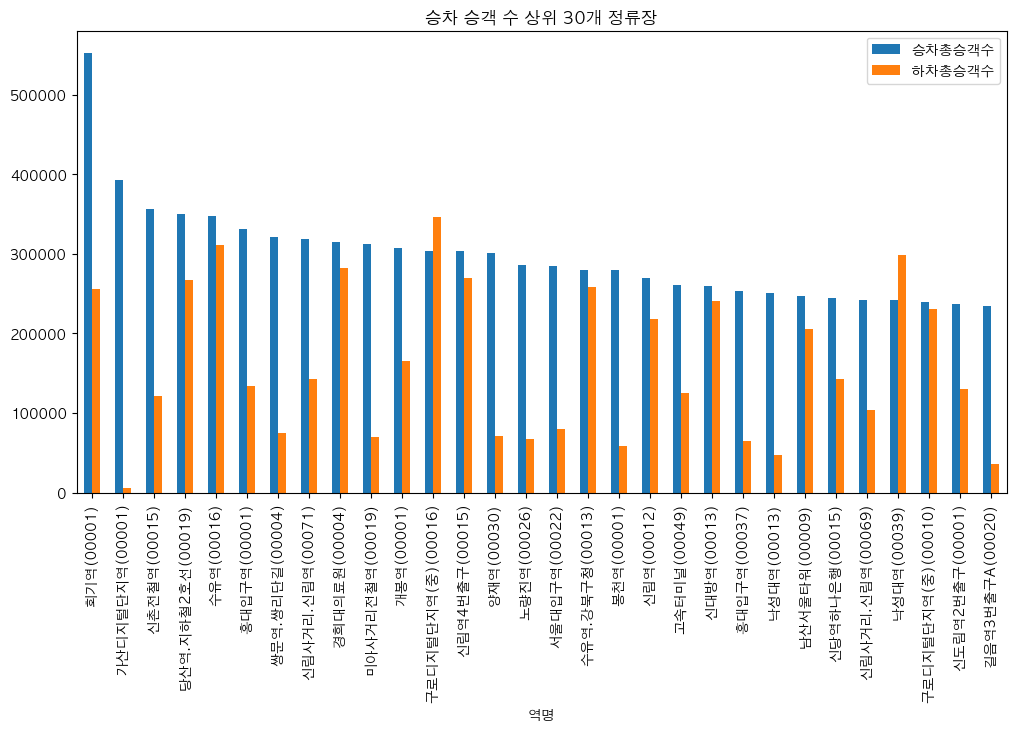

In [25]:
# 이제 데이터의 구조를 좀 이해했으니, 본격적으로 분포를 파악해볼게요
# 우리의 목표는 "좋은 정류장"을 찾는 것이기 때문에 먼저 좋은 정류장의 기준을 정해볼게요

### 저는 좋은 정류장이 사람들이 많이 타고 다니는 곳이라고 생각해요.
### 왜냐면! 그게 버스가 할 일 이니까요ㅋ
### 일단 그러면, 승차와 하차 승객 수의 분포를 보면 좋을 것 같아요

# 역명을 기준으로 groupby를 사용해서 승차 승객 수와 하차 승객 수의 합계를 구해볼게요
# 먼저 승차수 기준으로 보면?
bus_data.groupby('역명').agg({'승차총승객수':'sum', '하차총승객수':'sum'}).sort_values(by='승차총승객수', ascending=False).head(30).plot(kind='bar', figsize=(12,6), title='승차 승객 수 상위 30개 정류장')

# 이제 생각해볼 시간입니다.
# 이걸 보고 가만히 생각해보면?
# 1. 승차 승객 수가 많은 곳은 역 근처가 많다.  -> 당연함! 그럴듯하게 넘어갈 수 있어요
# 2.생각보다 승차와 하차 승객 수가 비례하는 경향성은 없는 것 같아요 -> 왜그런지는 잘 모르겠어요. 왜 둘의 편차가 클까요? 한번  하차수를 기준으로도 봐볼까요?

<Axes: title={'center': '하차 승객 수 상위 30개 정류장'}, xlabel='역명'>

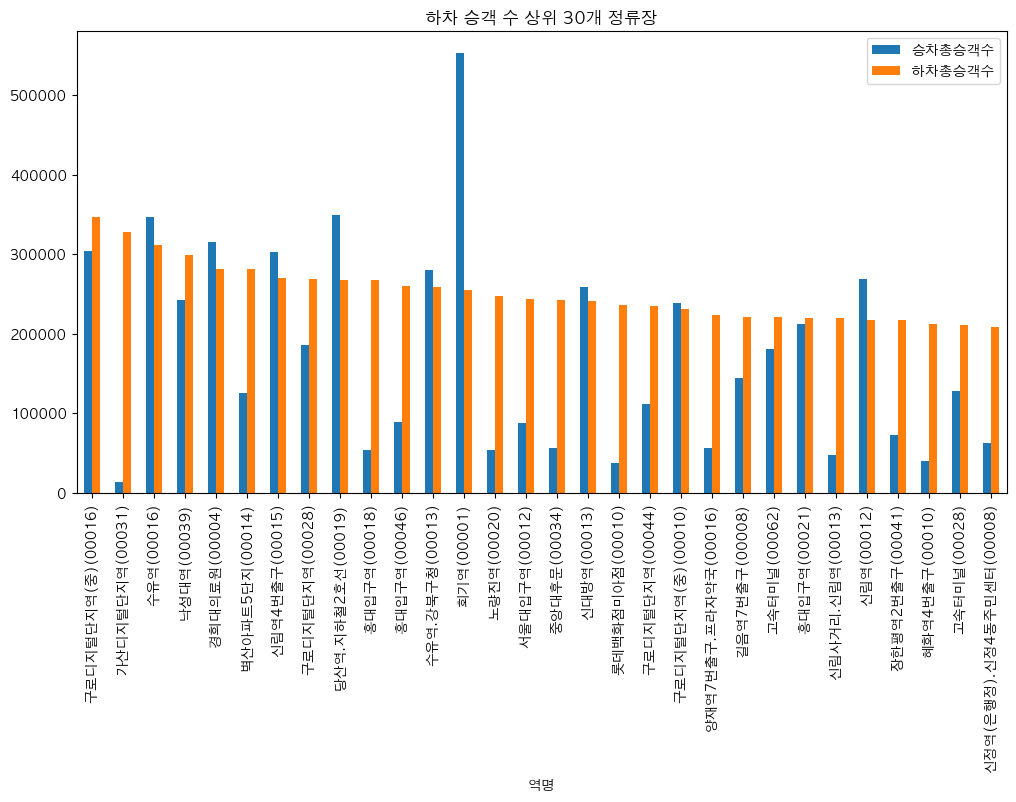

In [26]:
# 하차순으로도 봐볼게요.
bus_data.groupby('역명').agg({'승차총승객수':'sum', '하차총승객수':'sum'}).sort_values(by='하차총승객수', ascending=False).head(30).plot(kind='bar', figsize=(12,6), title='하차 승객 수 상위 30개 정류장')

# 이제 나타는게 있어요.
# 가산디지털 단지역의 경우!
# 가산디지털단지역(00001) -> 승차를 많이함
# 가산디지털단지역(00031) -> 하차를 많이함
# 일단 사람들은 가산에서 출발많이 타고, 많이 내린다는 건 명백해졌어요. 
# 하지만, 회기역의 경우에는 승차수는 많지만, 하차수는 많지가 않다는게 드러났어요. -> 왤까요? 모르겠네요.ㅋㅋ 회기역이 포함된 정류장을 더 디테일하게 찾아보면 좋을 것 같아요.

# 그러면 가산디지털단지역이 좋은 정류장일까요? 회기역이 좋은정류장일까요?
# 아니면 둘다 좋은 정류장일까요???? 

# 저는 가디역이 더 좋은 정류장 같아요. 왜냐면, 사람들이 많이 타고 많이 내리니까요ㅋㅋ
# 회기역은 사람들이 많이 타긴 하지만, 내리진 않으니까요.
# 물론, 이 기준이 절대적인 건 아니에요. 여러분들이 생각하는 좋은 정류장의 기준이 있을 수 있으니까요.
# 여러분들이 생각하는 좋은 정류장의 기준을 세워서, 그에 맞게 분석을 진행해보면 좋을 것 같아요.


# 지금 그래프 한개를 그렸는데 제 판단 기준이 나왔어요. -> 승차와 하차가 모두 많은 정류장이 다른 정류장보다 좋은 정류장이다!
# 그럼 이걸 수치로 환산할 수 있지 않을까요? 

# 우린 이걸 "지표 설계" 라고 해요.
# 즉, 기준을 잡고 지표를 데이터를 통해 만드는 거라고 생각하면 돼요. 일종의 KPI라고 생각하시면 편할 것 같아요.

## 2. 지표설계

In [27]:
# 저는 승차 + 하차 승객 수의 합계를 기준으로 지표를 설계해볼게요.
# 해당 지표도 아래 2가지 방향성이 있을 수 있을 것 같아요

# 1. 단순 이용량 기준
#  승차 + 하차 승객 수  -> 그냥 사람이 많이 타고 내리면 좋은 정류장이다! 
# 직관적! 

# 2. 균형 기준
# : 승차 승객 수와 하차 승객 수의 균형이 잘 맞는 정류장이 좋은 정류장이다!  
#  출근형(승차 집중) 퇴근형(하차 집중) 정류장보다는, 상권/생활 중심의 지속 이용 정류장을 ‘좋은 정류장’으로 본다!


# 위 2개를 통해 지표를 설계해볼게요.
# 1. 단순 이용량 기준

bus_usage = bus_data.groupby('역명').agg({'승차총승객수':'sum', '하차총승객수':'sum'}).reset_index() # groupby 
bus_usage['단순이용량지표'] = bus_usage['승차총승객수'] + bus_usage['하차총승객수']
bus_usage.sort_values(by='단순이용량지표', ascending=False)


,역명,승차총승객수,하차총승객수,단순이용량지표
40003,회기역(00001),553111,255530,808641
22737,수유역(00016),347203,311039,658242
4578,구로디지털단지역(중)(00016),303637,346164,649801
7978,당산역.지하철2호선(00019),349735,267702,617437
2980,경희대의료원(00004),315614,281970,597584
...,...,...,...,...
7719,다솔마을(00016),2,0,2
34520,중랑공영차고지(가상)(00172),0,1,1
10693,동작대로(가상)(00027),0,1,1
5545,근로복지공단(가상)(00057),0,1,1


In [28]:

# 2. 균형 기준
# 	분자: 승하차 인원의 차이 (불균형 정도)
#	분모: 전체 이용량 (규모 대비 균형 비율)
#	1에서 뺀 이유: 차이가 작을수록 값이 커지도록 (즉, 1에 가까울수록 균형 잡힌 정류장) 이라고 정의해볼게요
bus_usage['균형지표'] = 1 - (abs(bus_usage['승차총승객수'] - bus_usage['하차총승객수']) / (bus_usage['승차총승객수'] + bus_usage['하차총승객수']))



bus_usage.sort_values(by='균형지표', ascending=False)
 # 이렇게 하니까, 승객 수가 적은 정류장이 상위에 뜨네요 ㅋㅋ
 # 그럼 두 지표를 가중치를 주고, 순위를 매기면 적절히 섞이지 않을까요?
 

,역명,승차총승객수,하차총승객수,단순이용량지표,균형지표
37193,푸른수목원(00010),52,52,104,1.0
21288,성산대교(가상)(00021),8,8,16,1.0
36509,충암고교앞.대주피오레아파트(00025),127,127,254,1.0
37699,한강중학교(00136),87,87,174,1.0
16046,북서울꿈의숲(00151),94,94,188,1.0
...,...,...,...,...,...
10693,동작대로(가상)(00027),0,1,1,0.0
2299,개화역광역환승센터(00080),0,49,49,0.0
31102,은평권역공영차고지(00060),0,175,175,0.0
34509,중랑공영차고지(가상)(00090),0,23,23,0.0


## 3. 지표 통합 및 비교

In [29]:
 # 저는 사람이 많이 타는게 더 좋은 정류장이라고 생각해요
# 그래서 단순 이용량 지표에 가중치를 더 줘 볼게요!
# 근데 우리는 단순 이용량 지표는 그냥 승객수를 더했고, 균형 지표는 비율이기 때문에 두 지표의 지표의 범위가 달라요
# 그래서 우리는 단순 이용량 지표를 정규화 해주어야 해요! (0~1사이로 값을 맞추어 주어야합니다!)
# 이걸 우리는 Min-Max 정규화 라고 해요! (나중에 배워요)
# 수식으로 적으면 아래와 같아요

# 분자: 해당 정류장의 총 이용량에서 전체 중 최소값을 뺀 값  
# 분모: 전체 이용량 범위 (최대−최소)  
# 결과: 0~1 사이 값 → 1에 가까울수록 많이 이용되는 정류장  


bus_usage['단순이용량지표_정규화'] = (bus_usage['단순이용량지표'] - bus_usage['단순이용량지표'].min()) / (bus_usage['단순이용량지표'].max() - bus_usage['단순이용량지표'].min())
    
# 저는 사람이 많이 타는게 좋으니까 단순 이용량 지표에 0.7의 가중치를 주고, 균형 지표에 0.3의 가중치를 줄게요
# 그리고 두 지표를 합쳐서 최종 지표를 만들어볼게요!
bus_usage['좋은정류장지표'] = bus_usage['단순이용량지표_정규화'] * 0.7 + bus_usage['균형지표'] * 0.3

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_20527/958304050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = bus_usage.sort_values(by='좋은정류장지표', ascending=False).head(20),


<Axes: xlabel='역명', ylabel='좋은정류장지표'>

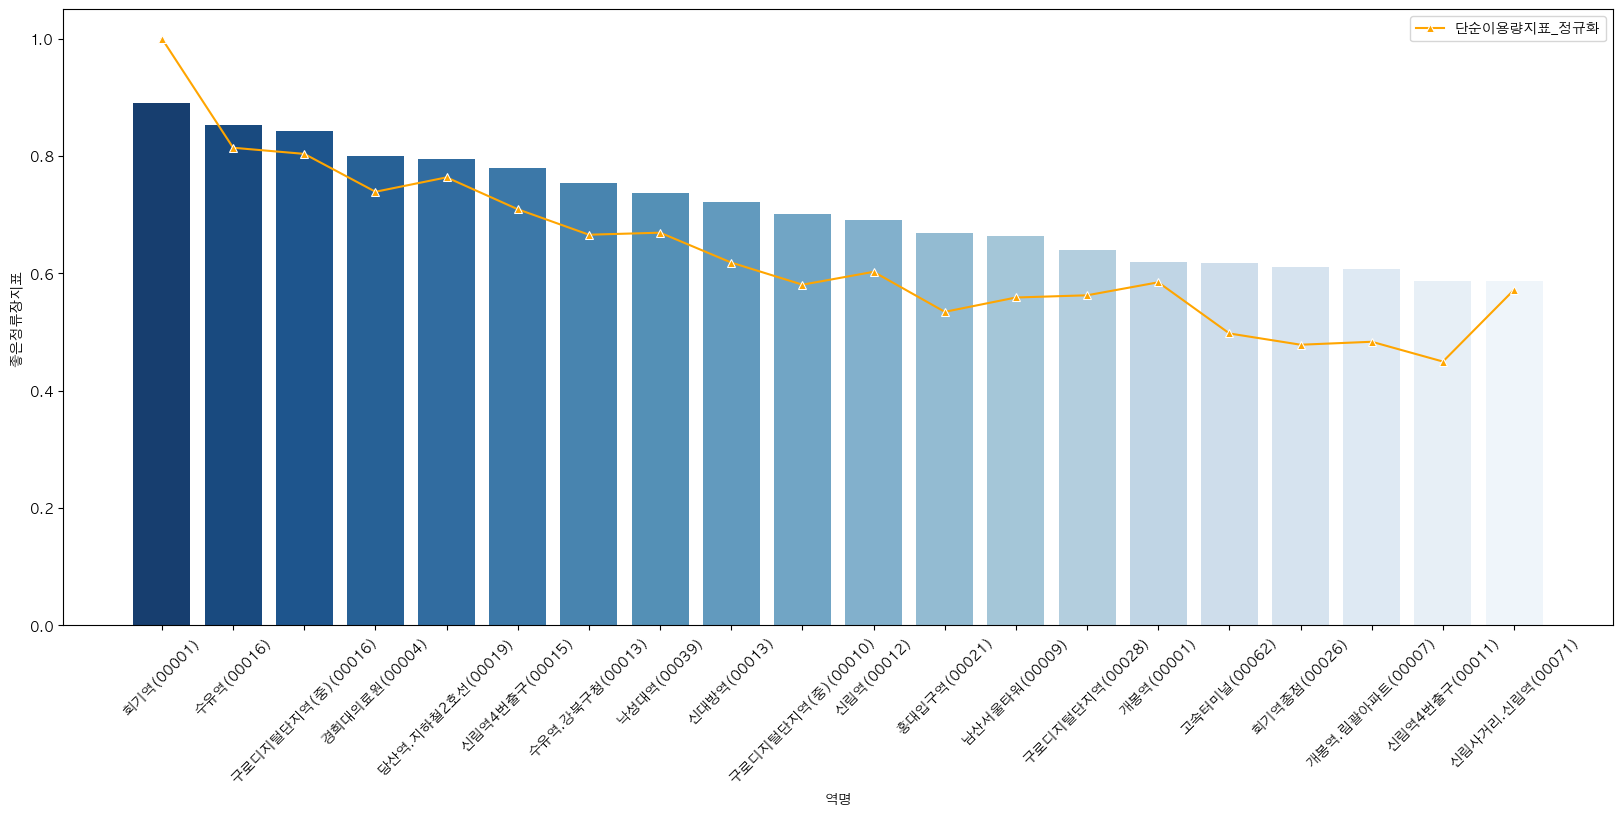

In [ ]:
bus_usage.sort_values(by='좋은정류장지표', ascending=False).head(20)
# 회기가 종합 점수 1등이네요
# 한번 각 지표별로 시각화를 해볼까요?

plt.figure(figsize=(20,8))
sns.barplot(data = bus_usage.sort_values(by='좋은정류장지표', ascending=False).head(20),
            x='역명',
            y='좋은정류장지표',
            palette='Blues_r')
plt.xticks(rotation=45)
sns.lineplot(data= bus_usage.sort_values(by='좋은정류장지표', ascending=False).head(20),
            x='역명',
            y='단순이용량지표_정규화', 
            marker='^',
            color ='orange',
            label='단순이용량지표_정규화')


# 대충 보니 추세가 어느정도 맞는데 상관분석까지 해볼까요?

<Axes: >

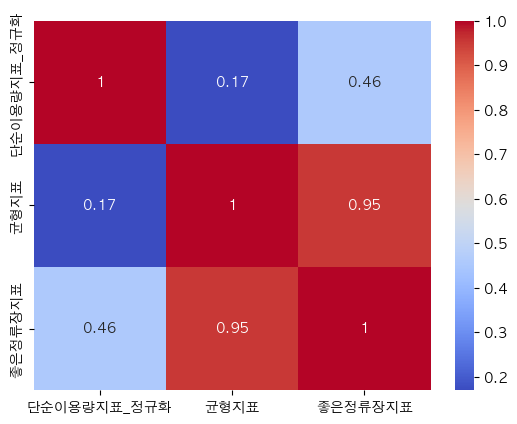

In [ ]:
# 상관분석 해보기
bus_usage[['단순이용량지표_정규화', '균형지표', '좋은정류장지표']].corr()
sns.heatmap(bus_usage[['단순이용량지표_정규화', '균형지표', '좋은정류장지표']].corr(), annot=True, cmap='coolwarm')

# 0.46이면 어느정도 상관성도 존재하네요! 신기합니당 ㅋ


# 추가필요)
- 날짜로 쪼개기
- 요일별 분석
- EDA 차트 추가